# Clustering & Types of Clustering Algorithms

## Practical Scikit-Learn Notebook

Topics:
- K-Means
- Hierarchical / Agglomerative Clustering
- DBSCAN
- Mean Shift
- Gaussian Mixture Models
- Silhouette Score
- PCA for visualization


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import (
    KMeans, AgglomerativeClustering, DBSCAN, MeanShift
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


## 1. Create and Scale Unlabeled Data

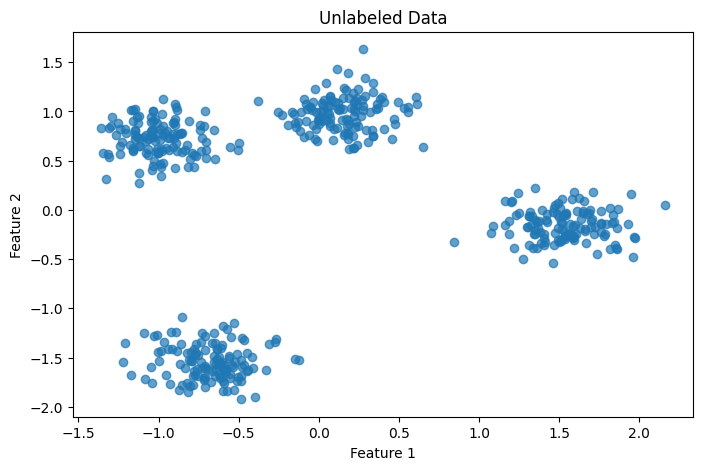

In [3]:
X, _ = make_blobs(
    n_samples=500,
    centers=4,
    cluster_std=1.1,
    random_state=42
)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.7)
plt.title("Unlabeled Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 2. K-Means Clustering

In [4]:
kmeans = KMeans(
    n_clusters=4,
    n_init=10,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("Labels:", np.unique(kmeans_labels))
print("Inertia:", kmeans.inertia_)


Labels: [0 1 2 3]
Inertia: 34.5857705110211


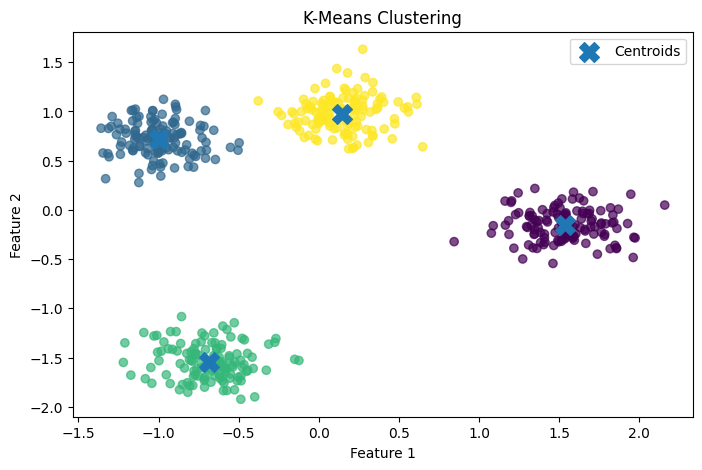

Silhouette Score: 0.7769343930490515


In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans_labels, alpha=0.7)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)
plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

print("Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))


## 3. Hierarchical / Agglomerative Clustering

In [6]:
hierarchical = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)
print("Labels:", np.unique(hierarchical_labels))


Labels: [0 1 2 3]


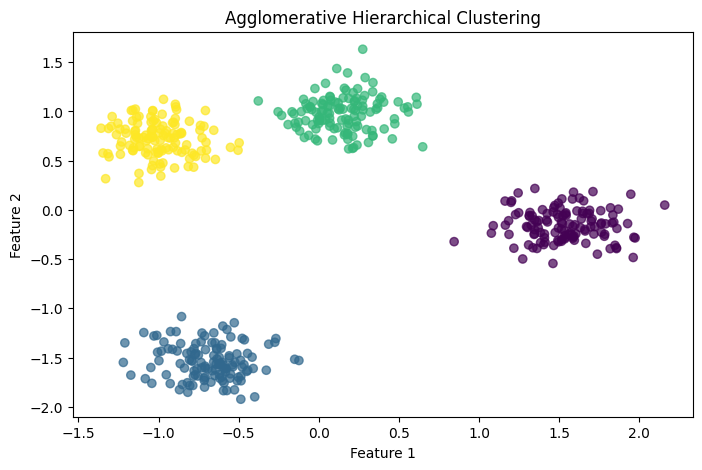

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=hierarchical_labels,
    alpha=0.7
)
plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 4. DBSCAN

In [8]:
dbscan = DBSCAN(
    eps=0.25,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("Labels:", np.unique(dbscan_labels))
print("Noise points:", np.sum(dbscan_labels == -1))


Labels: [-1  0  1  2  3]
Noise points: 1


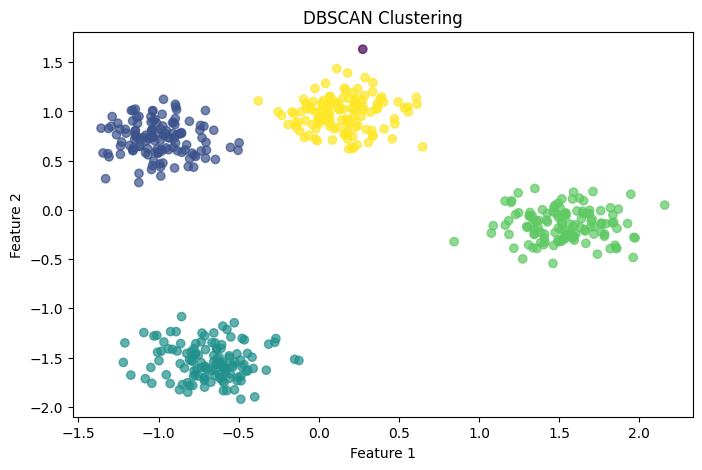

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=dbscan_labels,
    alpha=0.7
)
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 5. DBSCAN on Non-Linear Data

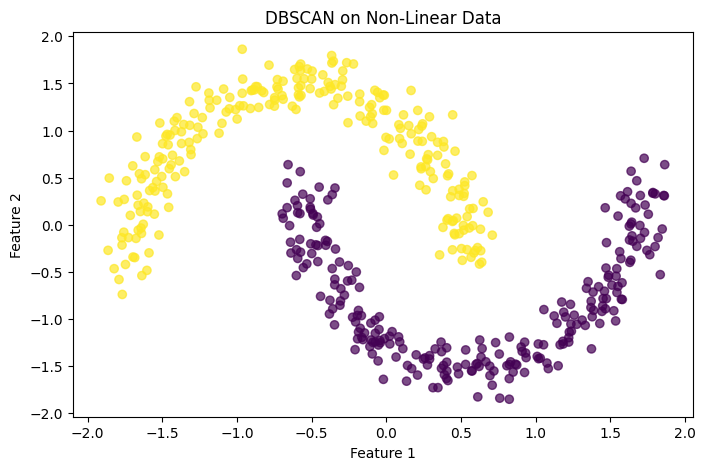

In [10]:
X_moons, _ = make_moons(
    n_samples=500,
    noise=0.08,
    random_state=42
)

X_moons = StandardScaler().fit_transform(X_moons)

moon_model = DBSCAN(eps=0.25, min_samples=5)
moon_labels = moon_model.fit_predict(X_moons)

plt.figure(figsize=(8, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=moon_labels, alpha=0.7)
plt.title("DBSCAN on Non-Linear Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


## 6. Mean Shift

In [11]:
mean_shift = MeanShift()
mean_shift_labels = mean_shift.fit_predict(X_scaled)

print("Detected clusters:", len(np.unique(mean_shift_labels)))


Detected clusters: 2


## 7. Gaussian Mixture Model

In [12]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

gmm.fit(X_scaled)

gmm_labels = gmm.predict(X_scaled)
gmm_probabilities = gmm.predict_proba(X_scaled)

print("Labels:", np.unique(gmm_labels))
print("First sample probabilities:", gmm_probabilities[0])


Labels: [0 1 2 3]
First sample probabilities: [5.26098139e-29 9.99997340e-01 4.48196219e-32 2.65965457e-06]


## 8. PCA for Visualization

Explained variance ratio: [0.5303609 0.4696391]


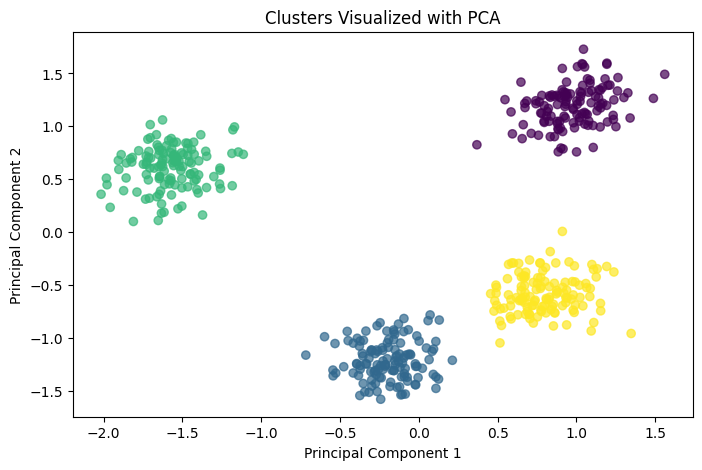

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Clusters Visualized with PCA")
plt.show()


## Conclusion

Clustering is an unsupervised learning task. Different algorithms define clusters differently:

- K-Means → centroids
- Hierarchical → nested groups
- DBSCAN → density
- Mean Shift → density modes
- GMM → probability distributions
